# Part 1: DBSCAN Clustering on Earthquake Data

This notebook implements DBSCAN clustering on earthquake data and explores the effects of different parameters.

## Objectives:
1. Load and preprocess earthquake data
2. Apply DBSCAN with various parameter settings
3. Visualize clustering results
4. Evaluate clustering quality
5. Explore parameter effects (eps and min_samples)
6. Compare with KMeans

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
from utils import load_earthquake_data, preprocess_data, calculate_epsilon_candidates, print_dataset_info

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Load and Explore Data

In [2]:
# Load data with selected features
# Using only a subset of meaningful numerical features
selected_features = ['magnitude', 'depth', 'latitude', 'longitude', 'sig']

df, X = load_earthquake_data(
    'data/earthquakes.csv',
    selected_features=selected_features,
    n_rows=1000  # Use first 1000 rows for faster processing
)

print_dataset_info(df, X, selected_features)

Dataset Information
Total records: 1000
Features used: ['magnitude', 'depth', 'latitude', 'longitude', 'sig']
Feature matrix shape: (1000, 5)

Feature statistics:
        magnitude        depth     latitude    longitude          sig
count  1000.00000  1000.000000  1000.000000  1000.000000  1000.000000
mean      4.78265    39.832057    28.032222    -9.337817   413.347000
std       1.06053    85.314719    19.242818   120.452016   237.778732
min       3.00000    -0.250000   -43.706400  -179.807000   138.000000
25%       3.70000     7.260000    24.195400  -111.755500   223.000000
50%       5.20000    10.000000    31.667350   -79.421600   432.000000
75%       5.60000    34.723000    37.470500   126.613250   503.000000
max       7.60000   639.503000    68.176100   179.972000  2419.000000


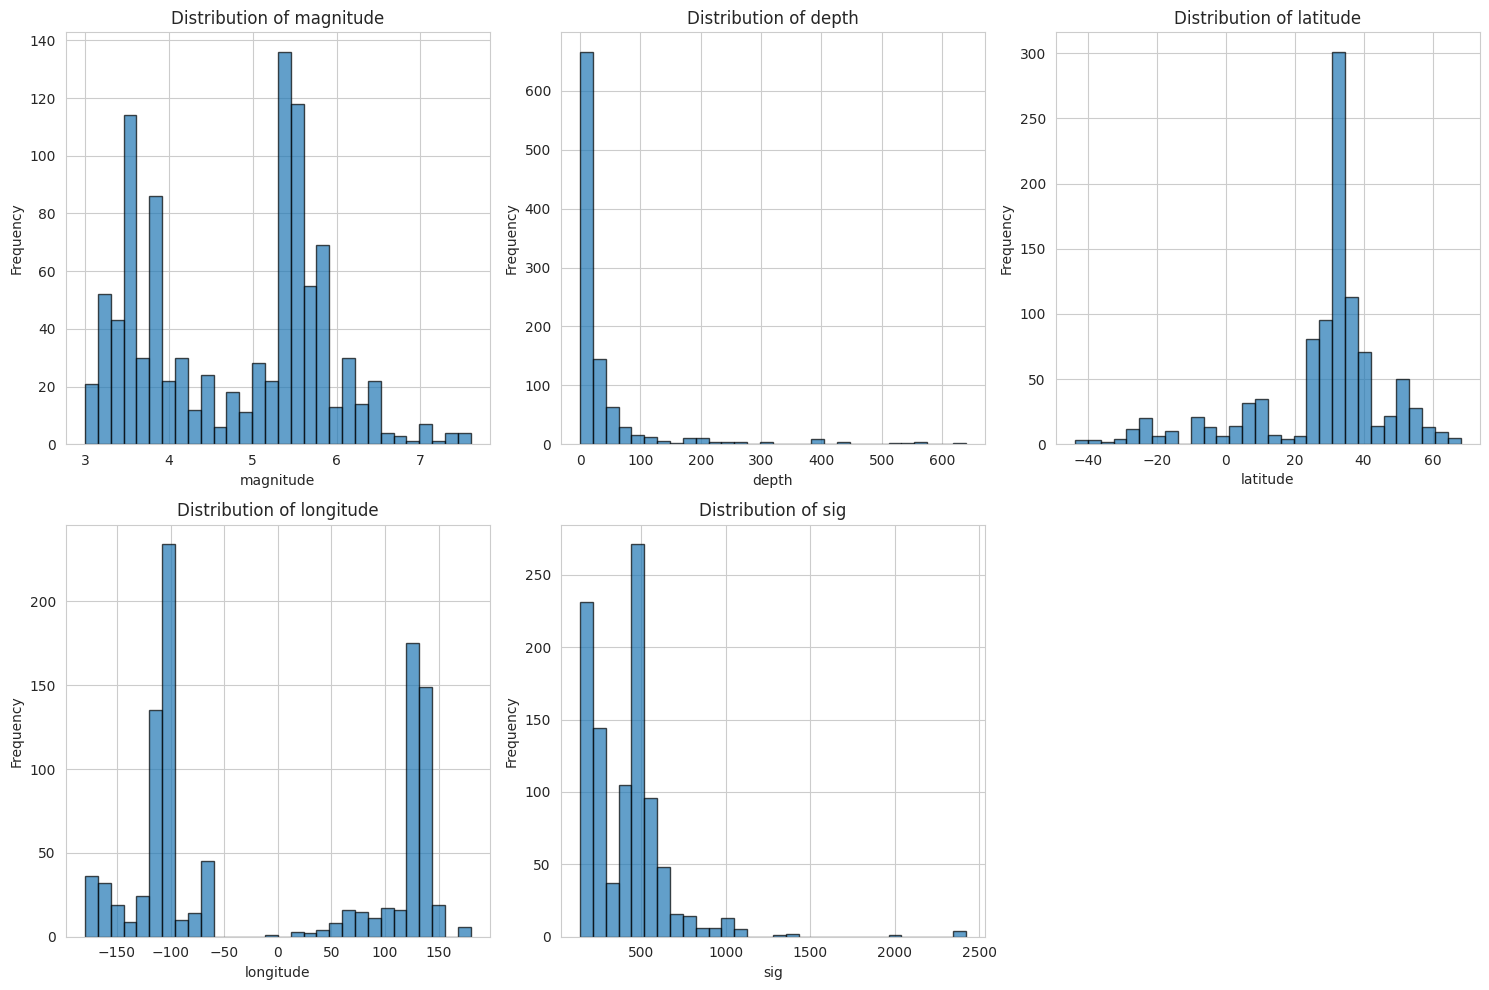

In [3]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(selected_features):
    axes[idx].hist(X[:, idx], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')

axes[-1].axis('off')  # Hide the last empty subplot
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [4]:
# Scale the data
X_scaled, scaler = preprocess_data(X, scale=True)

print("Data scaled successfully!")
print(f"Scaled data shape: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean(axis=0)}")
print(f"Std: {X_scaled.std(axis=0)}")

Data scaled successfully!
Scaled data shape: (1000, 5)
Mean: [ 5.82645043e-16 -2.13162821e-17  8.52651283e-17  0.00000000e+00
  9.94759830e-17]
Std: [1. 1. 1. 1. 1.]


## 4. Dimensionality Reduction for Visualization

PCA explained variance ratio: [0.53616774 0.20249688]
Total variance explained: 0.7387


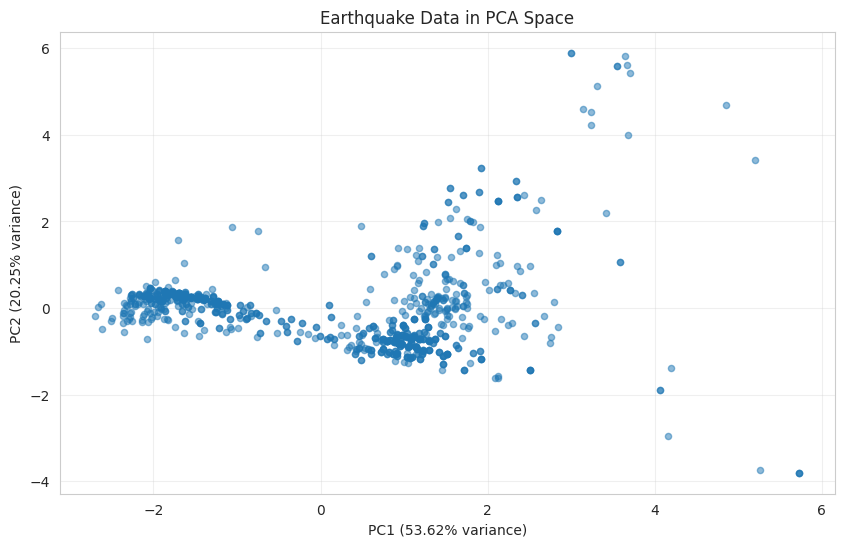

In [5]:
# Apply PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Visualize data in PCA space
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Earthquake Data in PCA Space')
plt.grid(True, alpha=0.3)
plt.show()

## 5. DBSCAN with Different Parameters

We'll experiment with different combinations of `eps` and `min_samples` to understand their effects.

In [6]:
# Calculate epsilon candidates using k-distance heuristic
eps_candidates = calculate_epsilon_candidates(X_scaled, n_neighbors=5)
print(f"Suggested epsilon values: {[f'{e:.3f}' for e in eps_candidates]}")

Suggested epsilon values: ['0.063', '0.177', '0.370', '0.702']


In [7]:
# Define parameter grid
params = [
    {'eps': 0.3, 'min_samples': 5},
    {'eps': 0.5, 'min_samples': 5},
    {'eps': 0.7, 'min_samples': 5},
    {'eps': 0.5, 'min_samples': 10},
    {'eps': 0.5, 'min_samples': 15},
    {'eps': 0.5, 'min_samples': 20},
]

results = []

for p in params:
    # Apply DBSCAN
    db = DBSCAN(eps=p['eps'], min_samples=p['min_samples'])
    labels = db.fit_predict(X_scaled)
    
    # Calculate metrics
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    # Silhouette score (only if we have more than 1 cluster)
    if n_clusters > 1 and n_noise < len(labels):
        # Remove noise points for silhouette calculation
        mask = labels != -1
        if mask.sum() > 0:
            sil = silhouette_score(X_scaled[mask], labels[mask])
            dbi = davies_bouldin_score(X_scaled[mask], labels[mask])
            chi = calinski_harabasz_score(X_scaled[mask], labels[mask])
        else:
            sil = np.nan
            dbi = np.nan
            chi = np.nan
    else:
        sil = np.nan
        dbi = np.nan
        chi = np.nan
    
    results.append({
        'params': p,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio,
        'silhouette': sil,
        'davies_bouldin': dbi,
        'calinski_harabasz': chi,
        'labels': labels
    })

# Display results table
results_df = pd.DataFrame([{
    'eps': r['params']['eps'],
    'min_samples': r['params']['min_samples'],
    'n_clusters': r['n_clusters'],
    'n_noise': r['n_noise'],
    'noise_ratio': f"{r['noise_ratio']:.2%}",
    'silhouette': f"{r['silhouette']:.3f}" if not np.isnan(r['silhouette']) else 'N/A',
    'davies_bouldin': f"{r['davies_bouldin']:.3f}" if not np.isnan(r['davies_bouldin']) else 'N/A',
} for r in results])

print("\n" + "="*80)
print("DBSCAN Results Summary")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


DBSCAN Results Summary
 eps  min_samples  n_clusters  n_noise noise_ratio silhouette davies_bouldin
 0.3            5          20      272      27.20%      0.414          0.669
 0.5            5          10      126      12.60%      0.471          0.670
 0.7            5           5       85       8.50%      0.513          0.566
 0.5           10           5      199      19.90%      0.553          0.667
 0.5           15           5      229      22.90%      0.565          0.617
 0.5           20           4      257      25.70%      0.565          0.700


## 6. Visualize Clustering Results

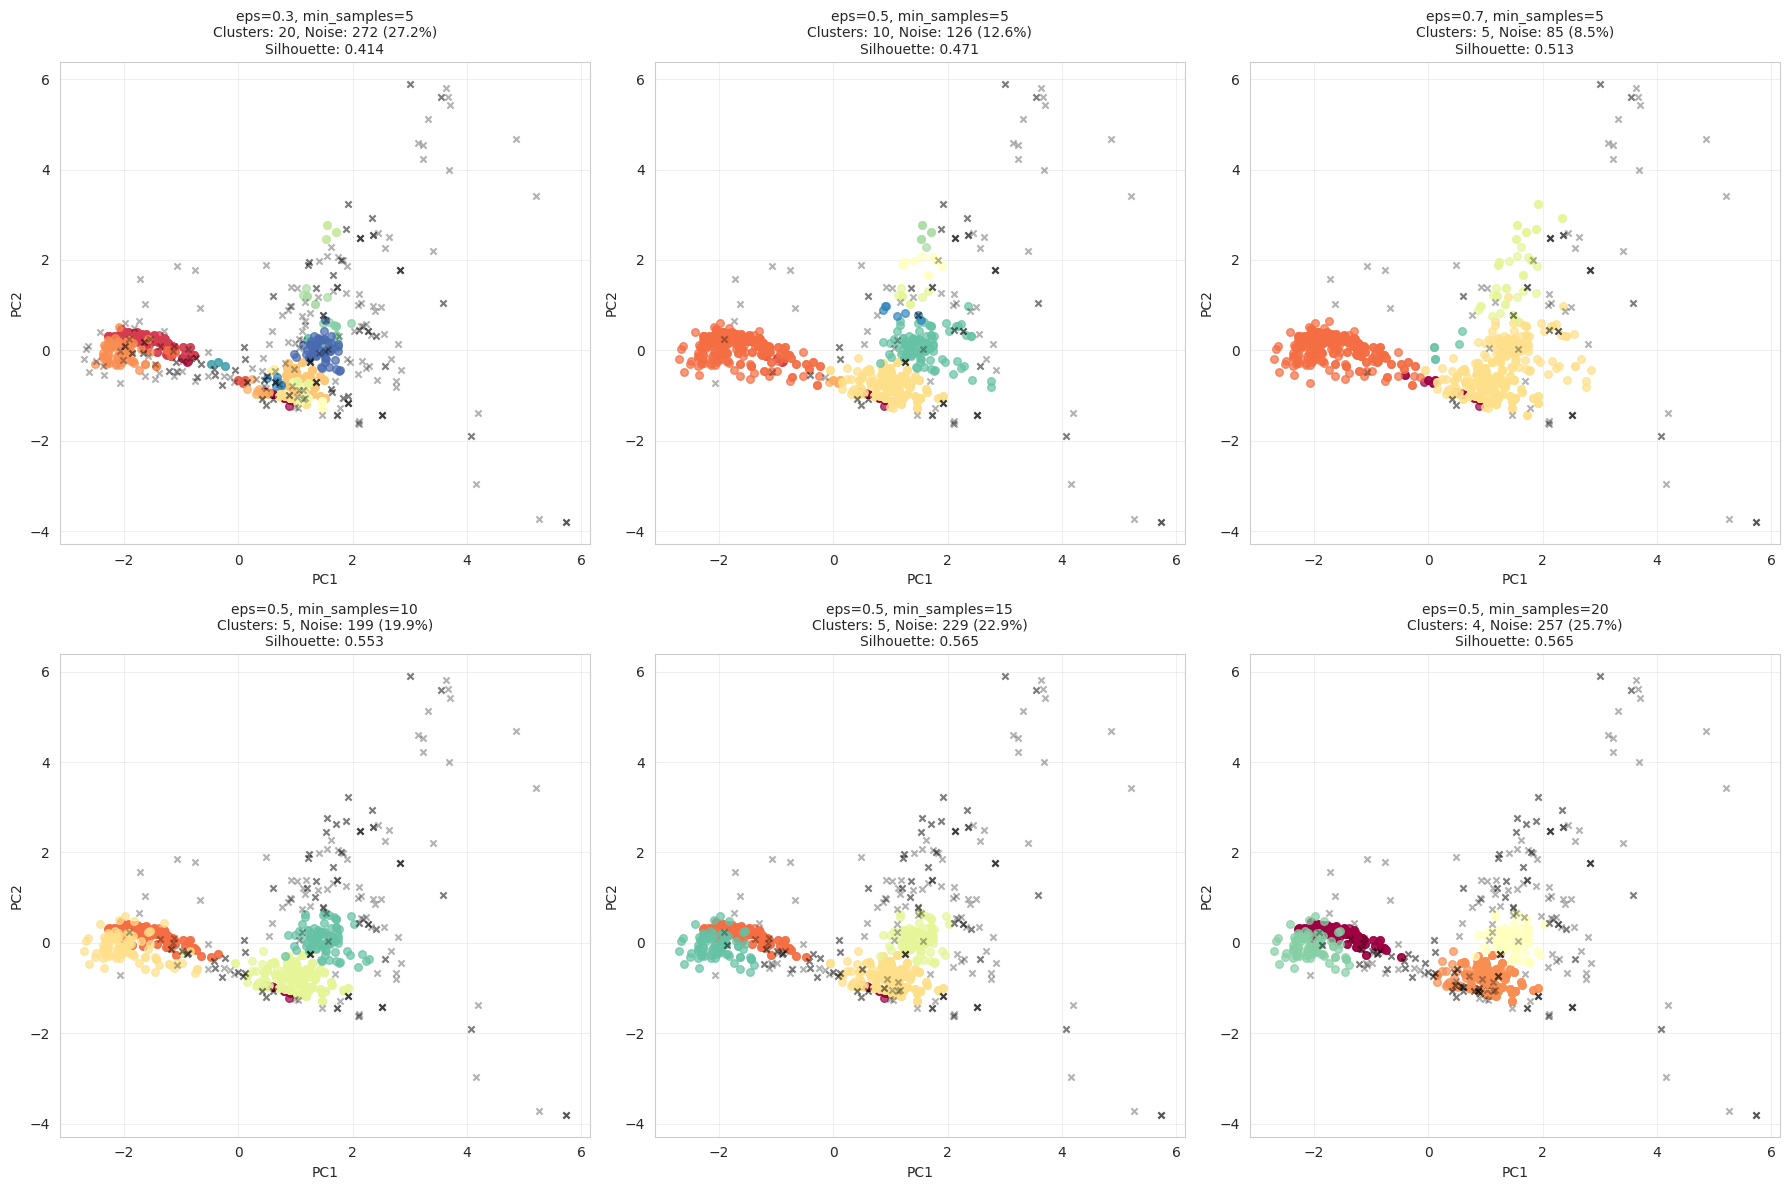

In [8]:
# Visualize all parameter combinations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, res in enumerate(results):
    labels = res['labels']
    unique_labels = set(labels)
    
    # Create color map
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Noise points in black
            col = 'black'
            marker = 'x'
            alpha = 0.3
            size = 20
        else:
            marker = 'o'
            alpha = 0.7
            size = 30
        
        class_member_mask = (labels == k)
        xy = X_pca[class_member_mask]
        
        axes[idx].scatter(
            xy[:, 0], xy[:, 1],
            c=[col], marker=marker,
            s=size, alpha=alpha,
            label=f'Cluster {k}' if k != -1 else 'Noise'
        )
    
    title = (
        f"eps={res['params']['eps']}, min_samples={res['params']['min_samples']}\n"
        f"Clusters: {res['n_clusters']}, Noise: {res['n_noise']} ({res['noise_ratio']:.1%})\n"
        f"Silhouette: {res['silhouette']:.3f}" if not np.isnan(res['silhouette']) else f"Silhouette: N/A"
    )
    axes[idx].set_title(title, fontsize=10)
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Parameter Exploration: Effect of eps

Exercise 1: Vary eps between 0.1 and 1.0 with step 0.05

In [9]:
# Vary eps
eps_values = np.arange(0.1, 1.05, 0.05)
min_samples_fixed = 5

eps_results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples_fixed)
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    eps_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio
    })

eps_df = pd.DataFrame(eps_results)

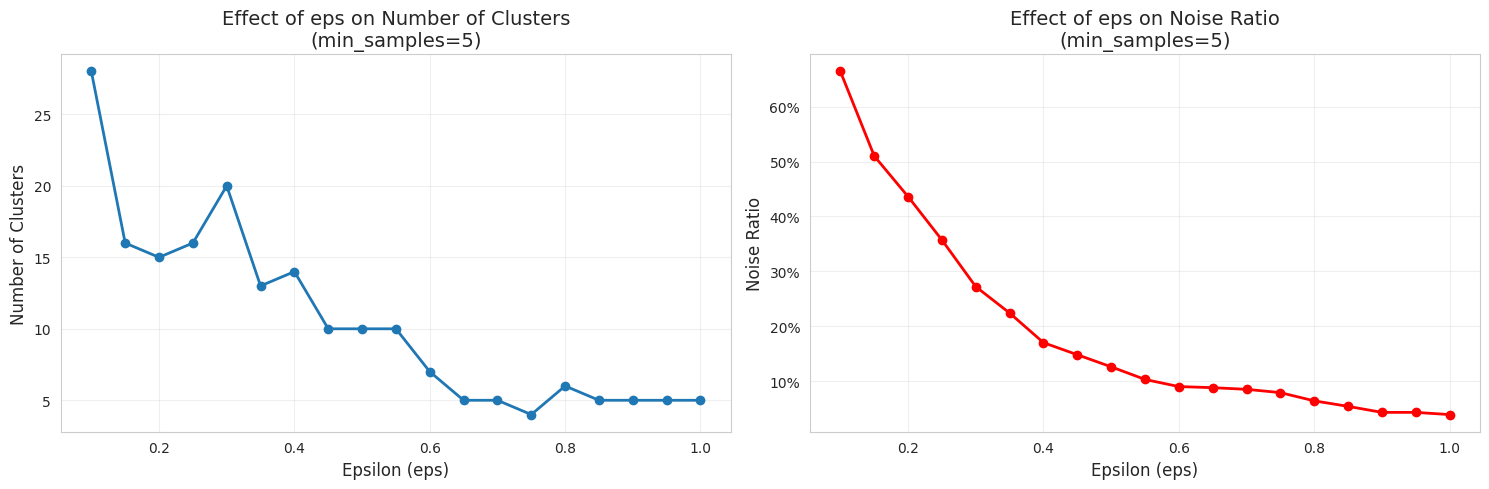

In [10]:
# Plot eps vs n_clusters and eps vs noise_ratio
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: eps vs n_clusters
axes[0].plot(eps_df['eps'], eps_df['n_clusters'], marker='o', linewidth=2, markersize=6)
axes[0].set_xlabel('Epsilon (eps)', fontsize=12)
axes[0].set_ylabel('Number of Clusters', fontsize=12)
axes[0].set_title('Effect of eps on Number of Clusters\n(min_samples=5)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Plot 2: eps vs noise_ratio
axes[1].plot(eps_df['eps'], eps_df['noise_ratio'], marker='o', color='red', linewidth=2, markersize=6)
axes[1].set_xlabel('Epsilon (eps)', fontsize=12)
axes[1].set_ylabel('Noise Ratio', fontsize=12)
axes[1].set_title('Effect of eps on Noise Ratio\n(min_samples=5)', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

## 8. Parameter Exploration: Effect of min_samples

Exercise 2: Vary min_samples with different values

In [11]:
# Vary min_samples
min_samples_values = [3, 5, 7, 10, 15, 20, 25, 30]
eps_fixed = 0.5

min_samples_results = []

for min_samples in min_samples_values:
    db = DBSCAN(eps=eps_fixed, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    min_samples_results.append({
        'min_samples': min_samples,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio
    })

min_samples_df = pd.DataFrame(min_samples_results)

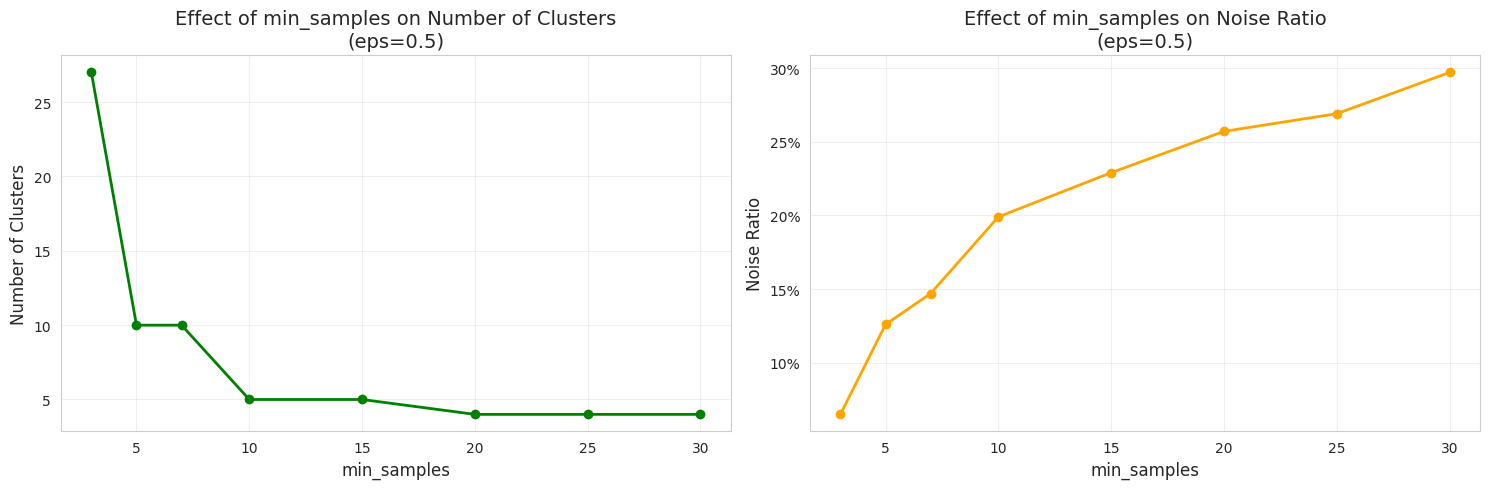

In [12]:
# Plot min_samples vs n_clusters and min_samples vs noise_ratio
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: min_samples vs n_clusters
axes[0].plot(min_samples_df['min_samples'], min_samples_df['n_clusters'], marker='o', linewidth=2, markersize=6, color='green')
axes[0].set_xlabel('min_samples', fontsize=12)
axes[0].set_ylabel('Number of Clusters', fontsize=12)
axes[0].set_title('Effect of min_samples on Number of Clusters\n(eps=0.5)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Plot 2: min_samples vs noise_ratio
axes[1].plot(min_samples_df['min_samples'], min_samples_df['noise_ratio'], marker='o', color='orange', linewidth=2, markersize=6)
axes[1].set_xlabel('min_samples', fontsize=12)
axes[1].set_ylabel('Noise Ratio', fontsize=12)
axes[1].set_title('Effect of min_samples on Noise Ratio\n(eps=0.5)', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

## 9. Comparison with KMeans

Exercise 3: Compare DBSCAN with KMeans

In [13]:
# Select best DBSCAN parameters from our experiments
best_eps = 0.5
best_min_samples = 10

# Apply DBSCAN
db = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = db.fit_predict(X_scaled)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Apply KMeans with different k values
k_values = [3, 5, 7, 10]
kmeans_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, kmeans_labels)
    dbi = davies_bouldin_score(X_scaled, kmeans_labels)
    chi = calinski_harabasz_score(X_scaled, kmeans_labels)
    
    kmeans_results.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': dbi,
        'calinski_harabasz': chi,
        'labels': kmeans_labels
    })

# Calculate DBSCAN metrics (without noise points)
mask = dbscan_labels != -1
if mask.sum() > 0 and n_clusters_dbscan > 1:
    dbscan_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_dbi = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_chi = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
else:
    dbscan_sil = np.nan
    dbscan_dbi = np.nan
    dbscan_chi = np.nan

print("\n" + "="*80)
print("Comparison: DBSCAN vs KMeans")
print("="*80)
print(f"\nDBSCAN (eps={best_eps}, min_samples={best_min_samples}):")
print(f"  Number of clusters: {n_clusters_dbscan}")
print(f"  Number of noise points: {list(dbscan_labels).count(-1)}")
print(f"  Silhouette Score: {dbscan_sil:.3f}" if not np.isnan(dbscan_sil) else "  Silhouette Score: N/A")
print(f"  Davies-Bouldin Index: {dbscan_dbi:.3f}" if not np.isnan(dbscan_dbi) else "  Davies-Bouldin Index: N/A")
print(f"  Calinski-Harabasz Index: {dbscan_chi:.1f}" if not np.isnan(dbscan_chi) else "  Calinski-Harabasz Index: N/A")

print("\nKMeans:")
for result in kmeans_results:
    print(f"  k={result['k']}: Silhouette={result['silhouette']:.3f}, DBI={result['davies_bouldin']:.3f}, CHI={result['calinski_harabasz']:.1f}")
print("="*80)


Comparison: DBSCAN vs KMeans

DBSCAN (eps=0.5, min_samples=10):
  Number of clusters: 5
  Number of noise points: 199
  Silhouette Score: 0.553
  Davies-Bouldin Index: 0.667
  Calinski-Harabasz Index: 1744.1

KMeans:
  k=3: Silhouette=0.544, DBI=0.857, CHI=736.9
  k=5: Silhouette=0.536, DBI=0.866, CHI=731.0
  k=7: Silhouette=0.515, DBI=0.819, CHI=749.8
  k=10: Silhouette=0.495, DBI=0.840, CHI=779.0


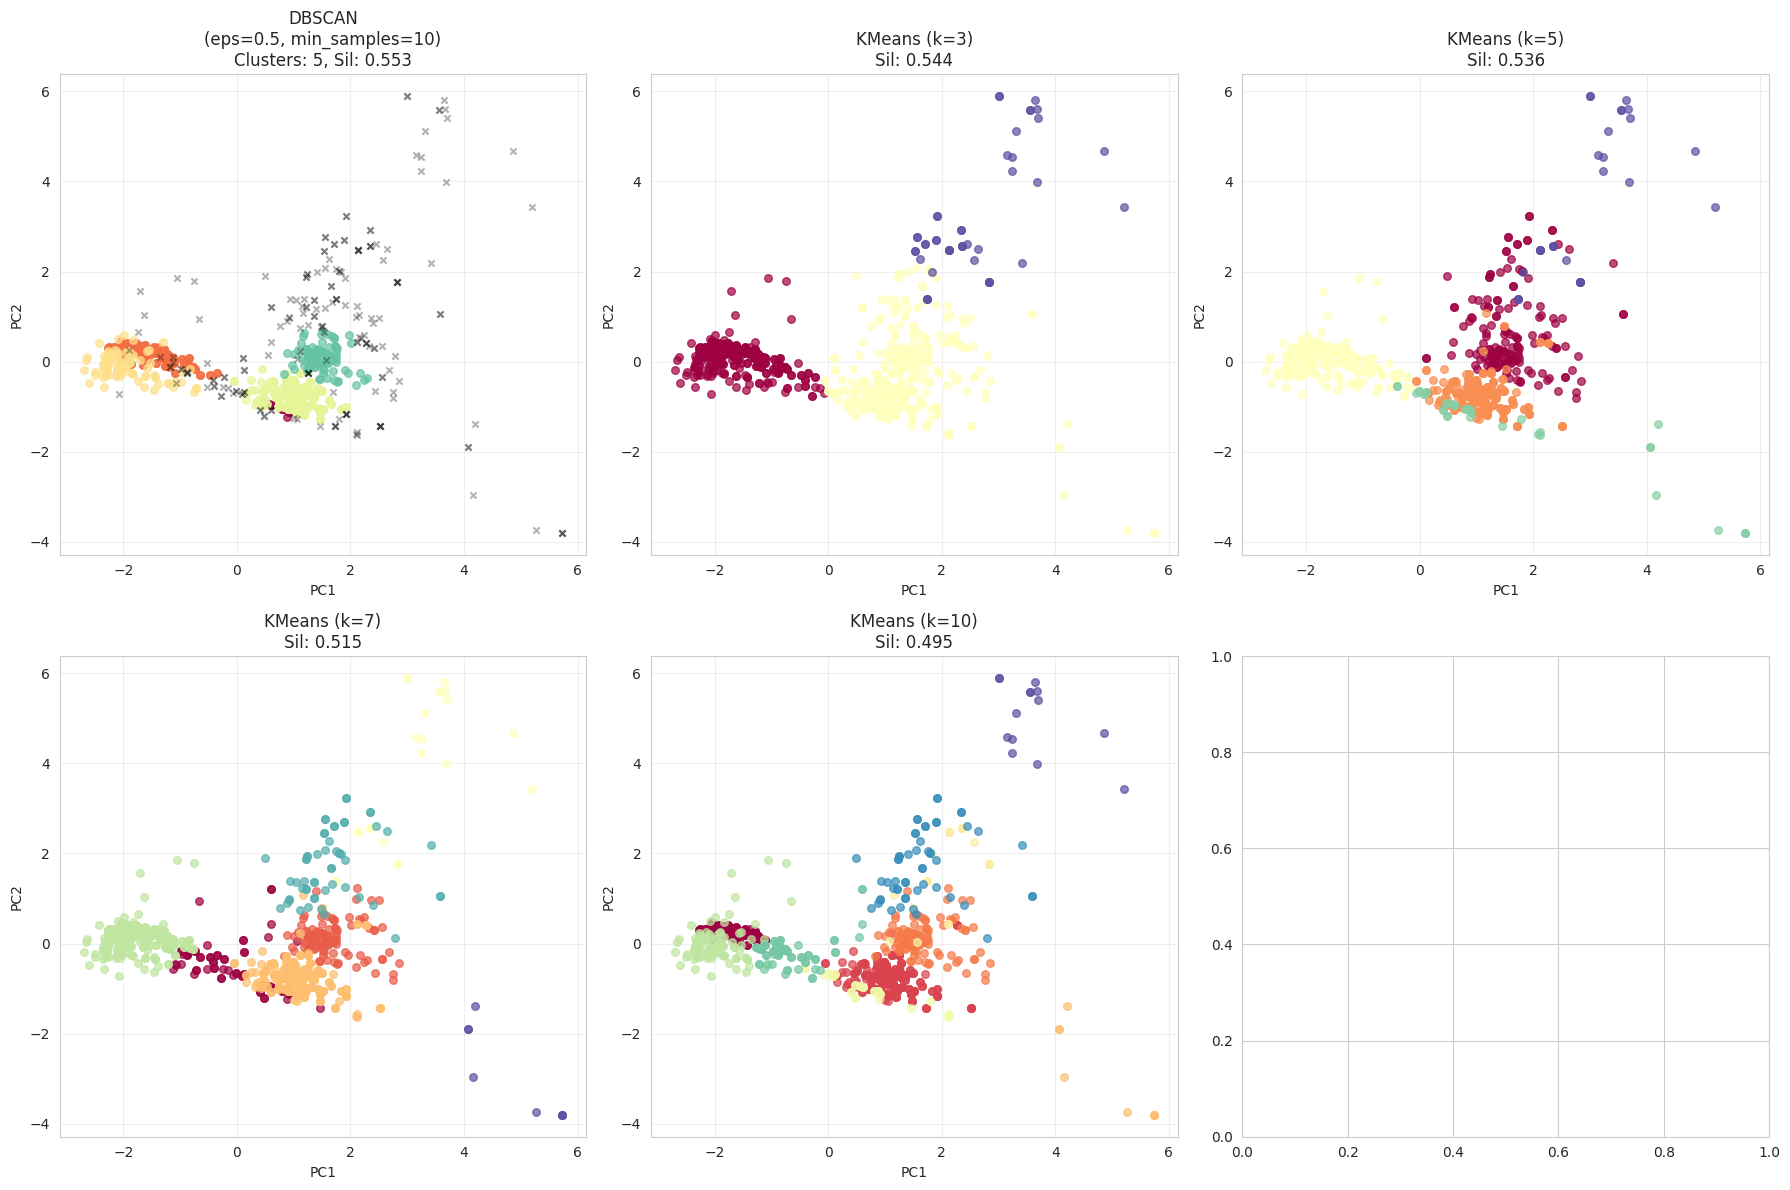

In [14]:
# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot DBSCAN
labels = dbscan_labels
unique_labels = set(labels)
colors_dbscan = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors_dbscan):
    if k == -1:
        col = 'black'
        marker = 'x'
        alpha = 0.3
        size = 20
    else:
        marker = 'o'
        alpha = 0.7
        size = 30
    
    class_member_mask = (labels == k)
    xy = X_pca[class_member_mask]
    axes[0, 0].scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=size, alpha=alpha)

axes[0, 0].set_title(f'DBSCAN\n(eps={best_eps}, min_samples={best_min_samples})\nClusters: {n_clusters_dbscan}, Sil: {dbscan_sil:.3f}' if not np.isnan(dbscan_sil) else f'DBSCAN\n(eps={best_eps}, min_samples={best_min_samples})\nClusters: {n_clusters_dbscan}', fontsize=12)
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].grid(True, alpha=0.3)

# Plot KMeans results
for idx, result in enumerate(kmeans_results[:5]):  # Plot first 5 k values
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    
    labels = result['labels']
    unique_labels = set(labels)
    colors_km = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
    
    for k, color in zip(unique_labels, colors_km):
        class_member_mask = (labels == k)
        xy = X_pca[class_member_mask]
        axes[row, col].scatter(xy[:, 0], xy[:, 1], c=[color], marker='o', s=30, alpha=0.7)
    
    axes[row, col].set_title(f"KMeans (k={result['k']})\nSil: {result['silhouette']:.3f}", fontsize=12)
    axes[row, col].set_xlabel('PC1')
    axes[row, col].set_ylabel('PC2')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Geographic Visualization

Let's visualize the clusters on a geographic map to see if they correspond to real seismic regions.

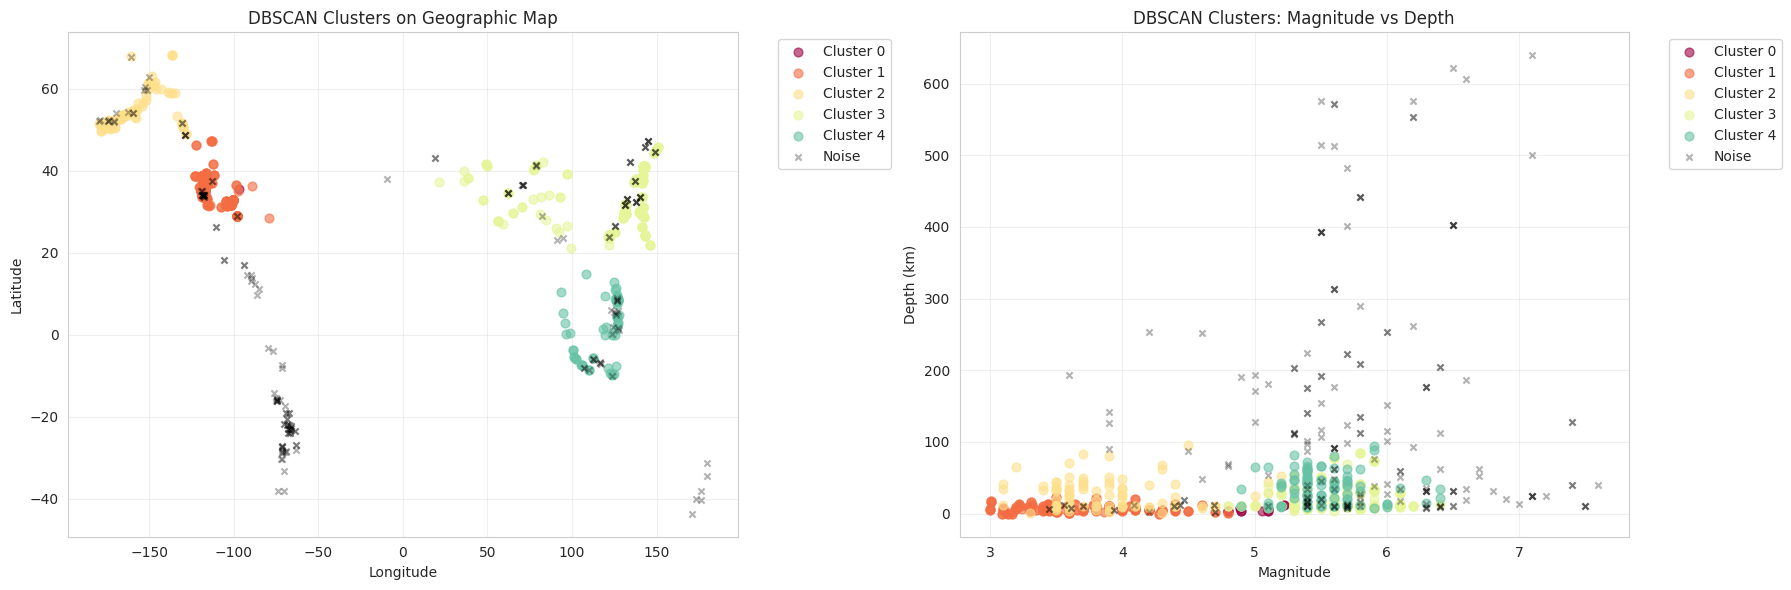

In [15]:
# Use best DBSCAN result
db = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = db.fit_predict(X_scaled)

# Plot on map
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: All data with clusters on geographic map
unique_labels = set(labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'black'
        marker = 'x'
        alpha = 0.3
        size = 20
    else:
        marker = 'o'
        alpha = 0.6
        size = 40
    
    class_member_mask = (labels == k)
    axes[0].scatter(
        df[class_member_mask]['longitude'],
        df[class_member_mask]['latitude'],
        c=[col], marker=marker, s=size, alpha=alpha,
        label=f'Cluster {k}' if k != -1 else 'Noise'
    )

axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('DBSCAN Clusters on Geographic Map')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: Magnitude vs Depth colored by cluster
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'black'
        marker = 'x'
        alpha = 0.3
        size = 20
    else:
        marker = 'o'
        alpha = 0.6
        size = 40
    
    class_member_mask = (labels == k)
    axes[1].scatter(
        df[class_member_mask]['magnitude'],
        df[class_member_mask]['depth'],
        c=[col], marker=marker, s=size, alpha=alpha,
        label=f'Cluster {k}' if k != -1 else 'Noise'
    )

axes[1].set_xlabel('Magnitude')
axes[1].set_ylabel('Depth (km)')
axes[1].set_title('DBSCAN Clusters: Magnitude vs Depth')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()